# Import

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import radon.complexity as cc
import radon.raw as raw

Dataframe creation from a csv file

In [2]:
df = pd.read_csv('function_lengths.csv')
df = df.sort_values(by='Length')

### Raw Data

In [3]:
print(df)

                                             Function  Length
17  \n\ndef test_DEVELOPMENT_PLAN(self):\n    asse...     518
3   \n\ndef __init__(self, args, name=None, descri...     520
25  def __init__(self, args, name=None, descriptio...     522
24  def run_command_until_success(convo, command, ...     524
34  def test_DEVELOPMENT_PLAN(self):\n    assert a...     525
12  \n\ndef get_arguments():\n    args = sys.argv[...     526
35  def test_rate_limit_error(self, mock_sleep, mo...     529
18  \n\n@patch('utils.llm_connection.requests.post...     553
36  def test_chat_completion_Architect(self, endpo...     560
23  def execute_command3(self, command, timeout=No...     571
10  \n\n@patch('helpers.cli.execute_command', retu...     591
13  \n\ndef create_gpt_chat_completion(messages: L...     606
9   \n\ndef get_project_description(self):\n    se...     621
29  def get_project_description(self):\n    self.p...     625
28  def continue_development2(self, iteration_conv...     633
8   \n\n

In the goal of studying the big functions, let's count how many call there are.

In [4]:
class ExtendedControlFlowVisitor(ast.NodeVisitor):
    def __init__(self):
        self.counts = {
            'if': 0,
            'for': 0,
            'while': 0,
            'try': 0,
            'except': 0,
            'def': 0,
            'return': 0,
            'assign': 0,
            'with': 0,
            'break': 0,
            'continue': 0,
            'raise': 0,
            'assert': 0
        }
    
    def visit_If(self, node):
        self.counts['if'] += 1
        self.generic_visit(node)
    
    def visit_For(self, node):
        self.counts['for'] += 1
        self.generic_visit(node)
    
    def visit_While(self, node):
        self.counts['while'] += 1
        self.generic_visit(node)
    
    def visit_Try(self, node):
        self.counts['try'] += 1
        self.generic_visit(node)
    
    def visit_ExceptHandler(self, node):
        self.counts['except'] += 1
        self.generic_visit(node)
    
    def visit_FunctionDef(self, node):
        self.counts['def'] += 1
        self.generic_visit(node)
    
    def visit_Return(self, node):
        self.counts['return'] += 1
        self.generic_visit(node)
    
    def visit_Assign(self, node):
        self.counts['assign'] += 1
        self.generic_visit(node)
    
    def visit_With(self, node):
        self.counts['with'] += 1
        self.generic_visit(node)
    
    def visit_Break(self, node):
        self.counts['break'] += 1
    
    def visit_Continue(self, node):
        self.counts['continue'] += 1
    
    def visit_Raise(self, node):
        self.counts['raise'] += 1
        self.generic_visit(node)
    
    def visit_Assert(self, node):
        self.counts['assert'] += 1
        self.generic_visit(node)
    
    def report(self):
        return self.counts

Let's get some other metrics like the cyclic complexity, the number of lines and the total number of statements

In [5]:
def analyze_function(code):
    # Analyze cyclomatic complexity
    visitor = cc.ComplexityVisitor.from_code(code)
    cyclomatic_complexity = sum([block.complexity for block in visitor.blocks])
    
    # Analyze raw metrics
    raw_metrics = raw.analyze(code)
    length = raw_metrics.loc  # Lines of code
    num_statements = raw_metrics.sloc  # Source lines of code
    
    # Analyze control flow
    control_flow_counts = analyze_control_flow(code)
    
    return cyclomatic_complexity, length, num_statements, control_flow_counts

def analyze_control_flow(code):
    tree = ast.parse(code)
    visitor = ExtendedControlFlowVisitor()
    visitor.visit(tree)
    return visitor.report()

Now let's pass the functions in the function and separate each value for interpretation and visualisation

In [6]:
# Analyze each function
metrics = [analyze_function(f) for f in df['Function']]

# Extract metrics for plotting
cyclomatic_complexities = [m[0] for m in metrics]
lengths = [m[1] for m in metrics]
num_statements = [m[2] for m in metrics]
control_flow_metrics = [m[3] for m in metrics]

# Separate control flow counts for each type
if_counts = [cf['if'] for cf in control_flow_metrics]
for_counts = [cf['for'] for cf in control_flow_metrics]
while_counts = [cf['while'] for cf in control_flow_metrics]
try_counts = [cf['try'] for cf in control_flow_metrics]
except_counts = [cf['except'] for cf in control_flow_metrics]
def_counts = [cf['def'] for cf in control_flow_metrics]
return_counts = [cf['return'] for cf in control_flow_metrics]
assign_counts = [cf['assign'] for cf in control_flow_metrics]
with_counts = [cf['with'] for cf in control_flow_metrics]
break_counts = [cf['break'] for cf in control_flow_metrics]
continue_counts = [cf['continue'] for cf in control_flow_metrics]
raise_counts = [cf['raise'] for cf in control_flow_metrics]
assert_counts = [cf['assert'] for cf in control_flow_metrics]

# Names for the functions
function_names = [f'Function {i+1}' for i in range(len(df['Function']))]

# Interpretation

Let's start with the "Length" found in the csv file

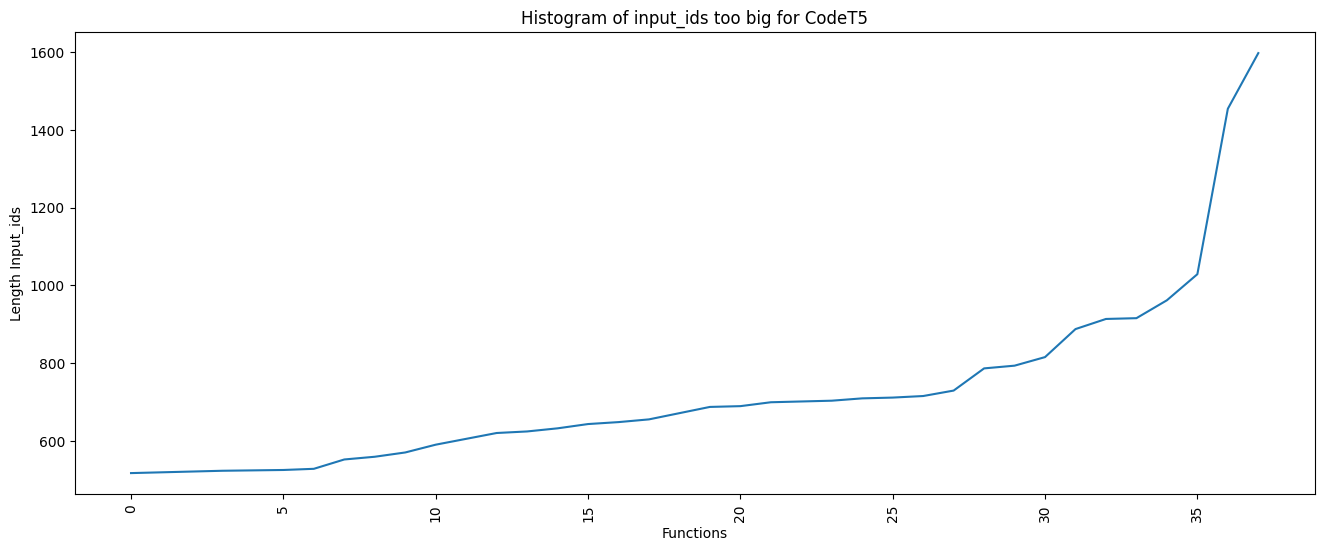

In [7]:
plt.figure(figsize=(16, 6))
plt.plot(df['Length'].array)
plt.xlabel('Functions')
plt.ylabel('Length Input_ids')
plt.title('Histogram of input_ids too big for CodeT5')
plt.xticks(rotation=90)
plt.show()

Let's compare it to the number of characters per function as well as the max number of characters in one line

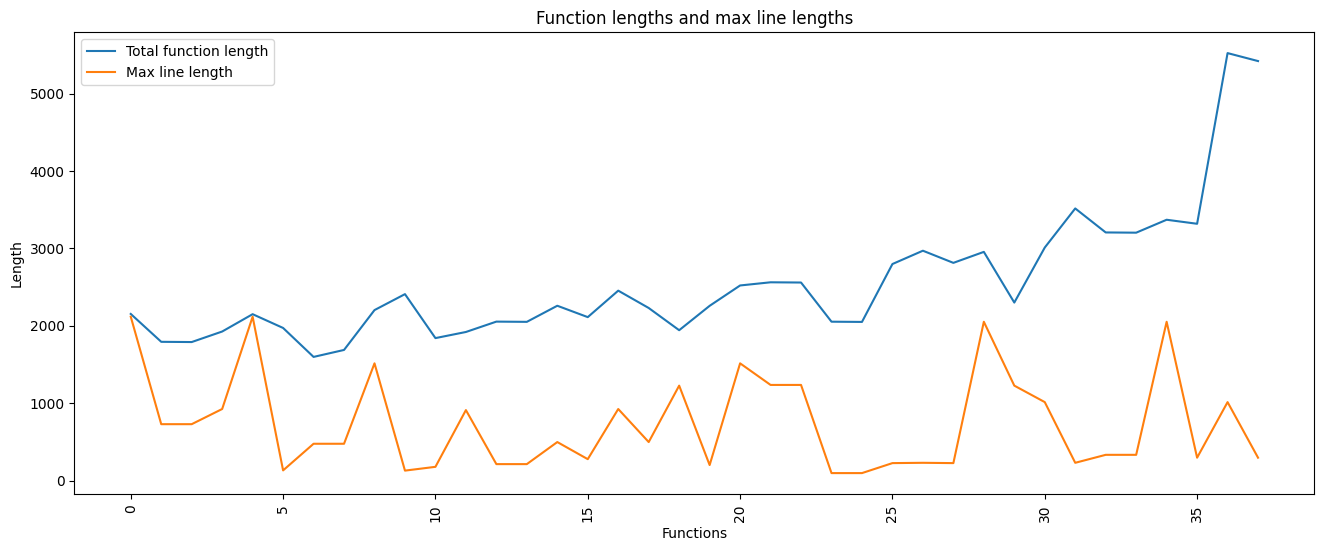

In [8]:
df['Total function length'] = [len(function) for function in df['Function']]
df['Max line length'] = [max(len(line) for line in function.split('\n')) for function in df['Function']]

plt.figure(figsize=(16, 6))
plt.plot(df['Total function length'].array, label='Total function length')
plt.plot(df['Max line length'].array, label='Max line length')
plt.xlabel('Functions')
plt.ylabel('Length')
plt.title("Function lengths and max line lengths")
plt.legend()
plt.xticks(rotation=90)
plt.show()

Some variation can be found compared to the Length token of CodeT5.\
Let's put a number to this variation.

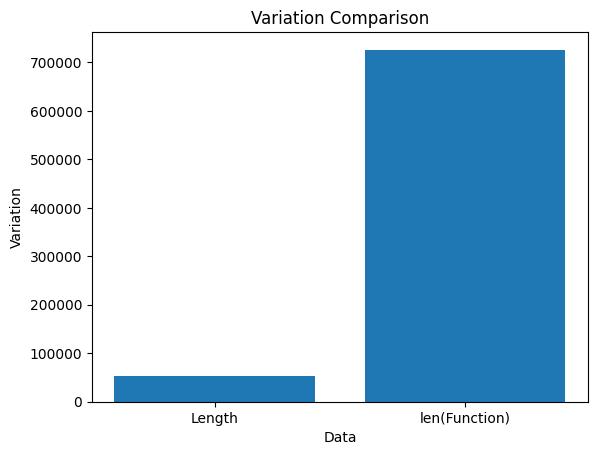

In [9]:
length_array = df['Length'].array
function_lengths = [len(function) for function in df['Function']]

length_var = np.var(length_array)
function_var = np.var(function_lengths)
variation_diff = length_var - function_var

fig, ax = plt.subplots()
ax.bar(['Length', 'len(Function)'], [length_var, function_var])
ax.set_title('Variation Comparison')
ax.set_xlabel('Data')
ax.set_ylabel('Variation')

plt.show()

Now let's visualize the cyclic complexity, the number of lines and the total number of statements

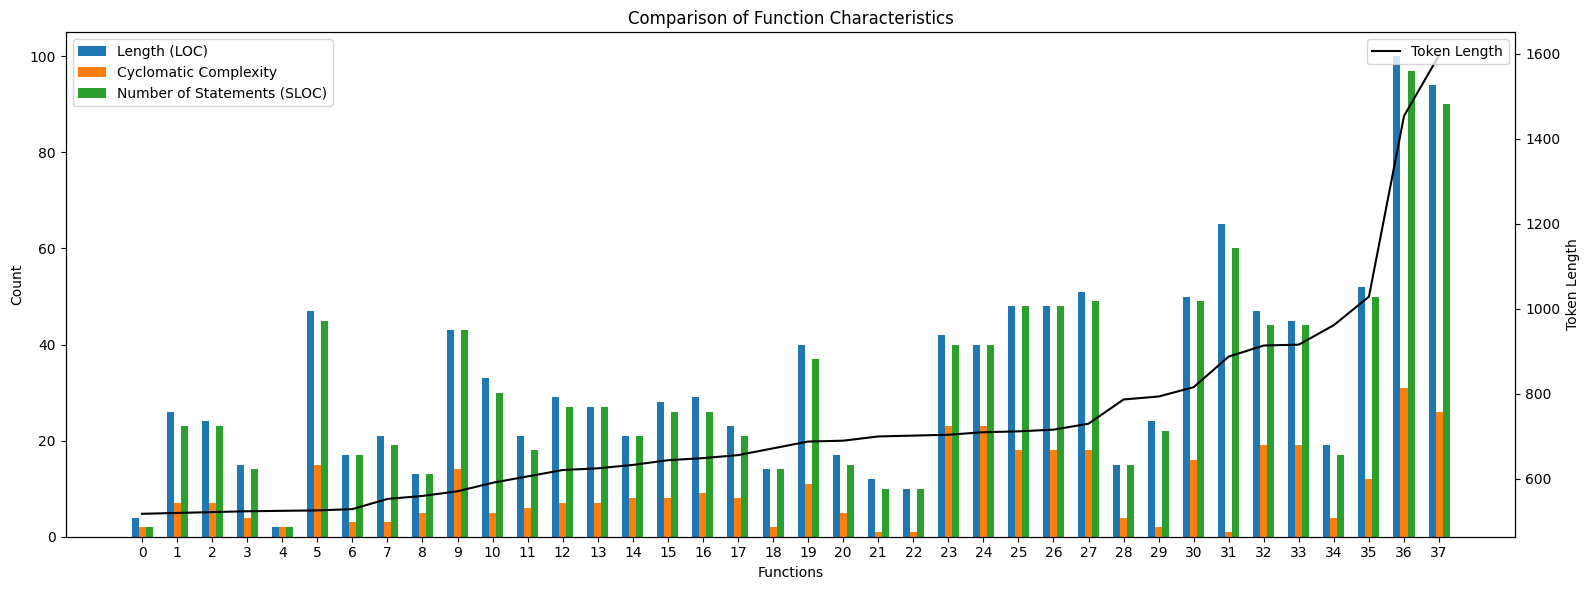

In [10]:
# Add LOC, cyclomatic complexity and SLOC to the df
df['LOC'] = lengths
df['Cyclomatic Complexity'] = cyclomatic_complexities
df['SLOC'] = num_statements

# Create a bar chart for each metric
x = np.arange(len(function_names))
width = 0.2  # the width of the bars

fig, ax1 = plt.subplots(figsize=(16, 6))

rects1 = ax1.bar(x - width, df['LOC'], width, label='Length (LOC)')
rects2 = ax1.bar(x, df['Cyclomatic Complexity'], width, label='Cyclomatic Complexity')
rects3 = ax1.bar(x + width, df['SLOC'], width, label='Number of Statements (SLOC)')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax1.set_xlabel('Functions')
ax1.set_ylabel('Count')
ax1.set_title('Comparison of Function Characteristics')
ax1.set_xticks(x)
ax1.legend()

# Add a second y-axis for the line plot
ax2 = ax1.twinx()
ax2.plot(x, df['Length'].array, color='black', label='Token Length')
ax2.set_ylabel('Token Length')
ax2.legend(loc='upper right')

fig.tight_layout()

plt.show()

We can see that the 3 metrics globally follows the growth of the token length with some exceptions that are logical seeing the maximum line length in a previous graph.

Now let's see the calls.

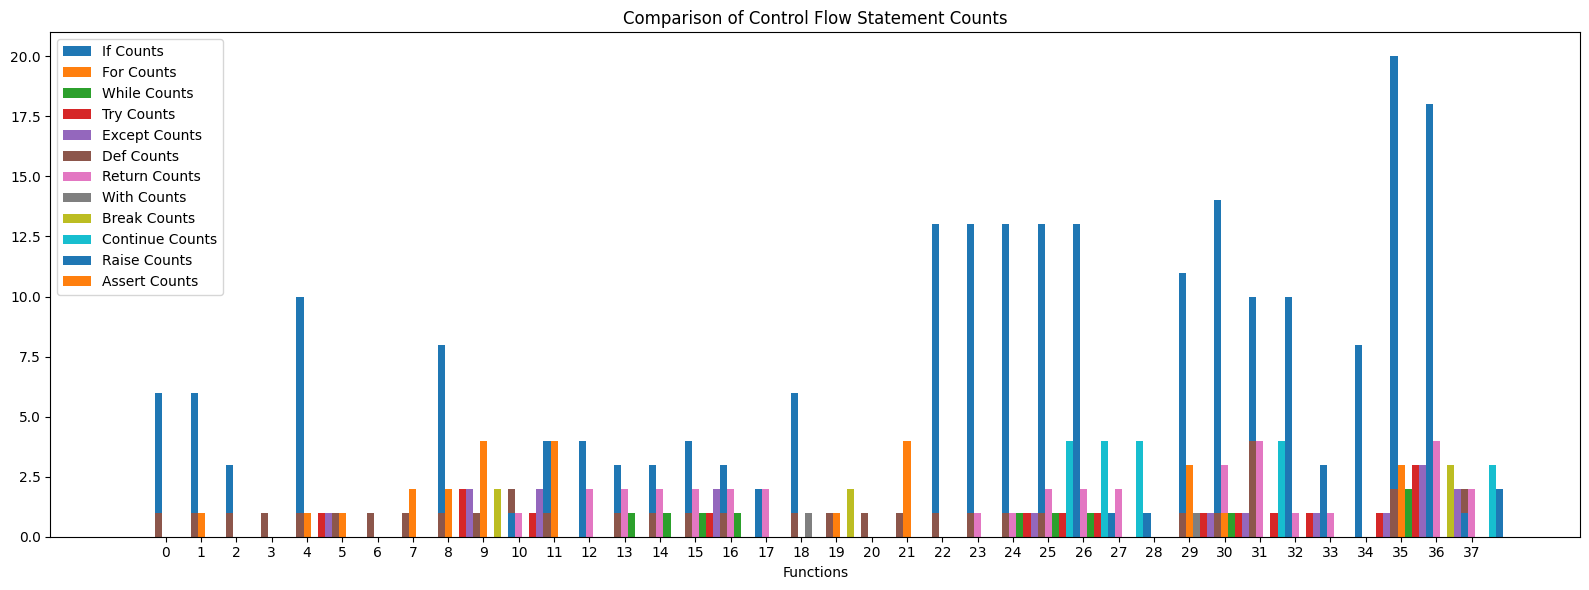

In [11]:
# Add all the rects to the DataFrame
df['If Counts'] = if_counts
df['For Counts'] = for_counts
df['While Counts'] = while_counts
df['Try Counts'] = try_counts
df['Except Counts'] = except_counts
df['Def Counts'] = def_counts
df['Return Counts'] = return_counts
df['With Counts'] = with_counts
df['Break Counts'] = break_counts
df['Continue Counts'] = continue_counts
df['Raise Counts'] = raise_counts
df['Assert Counts'] = assert_counts

# Create a bar chart for control flow counts
fig, ax = plt.subplots(figsize=(16, 6))

rects1 = ax.bar(x - 6*width, df['If Counts'], width, label='If Counts')
rects2 = ax.bar(x - 5*width, df['For Counts'], width, label='For Counts')
rects3 = ax.bar(x - 4*width, df['While Counts'], width, label='While Counts')
rects4 = ax.bar(x - 3*width, df['Try Counts'], width, label='Try Counts')
rects5 = ax.bar(x - 2*width, df['Except Counts'], width, label='Except Counts')
rects6 = ax.bar(x - width, df['Def Counts'], width, label='Def Counts')
rects8 = ax.bar(x, df['Return Counts'], width, label='Return Counts')
rects12 = ax.bar(x + width, df['With Counts'], width, label='With Counts')
rects13 = ax.bar(x + 2*width, df['Break Counts'], width, label='Break Counts')
rects14 = ax.bar(x + 3*width, df['Continue Counts'], width, label='Continue Counts')
rects15 = ax.bar(x + 4*width, df['Raise Counts'], width, label='Raise Counts')
rects16 = ax.bar(x + 5*width, df['Assert Counts'], width, label='Assert Counts')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Functions')
ax.set_title('Comparison of Control Flow Statement Counts')
ax.set_xticks(x)
ax.legend()

fig.tight_layout()

plt.show()

We can see a global increase in calls corresponding to an increased token length.\
Let's add them all together to get a count of calls per issue.

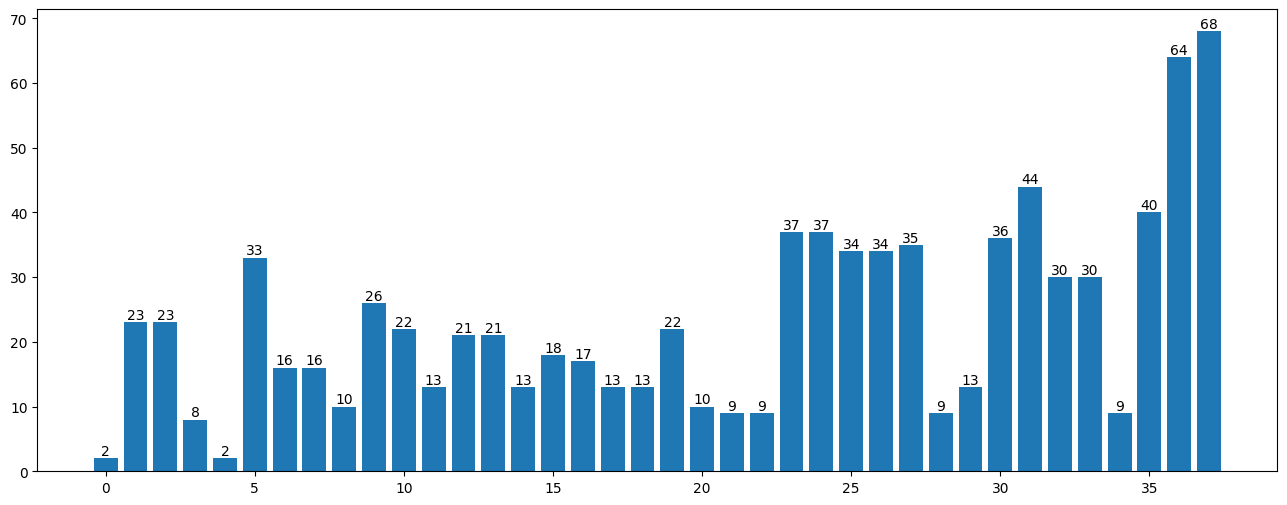

In [12]:
data = [sum(x) for x in zip(
    if_counts,
    for_counts,
    while_counts,
    try_counts,
    except_counts,
    def_counts,
    return_counts,
    assign_counts,
    with_counts,
    break_counts,
    continue_counts,
    raise_counts,
    assert_counts)]

df['total_counts'] = data

plt.subplots(figsize=(16, 6))
plt.bar(range(len(df['total_counts'])), df['total_counts'])
for i, v in enumerate(df['total_counts']):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

Indeed the functions with the bigger number of calls are the ones with the bigger token length.\
But that's not all that caracterize those functions to get a big token length.

Let's see if some datas are correlated between each other to understand the notion of big functions.

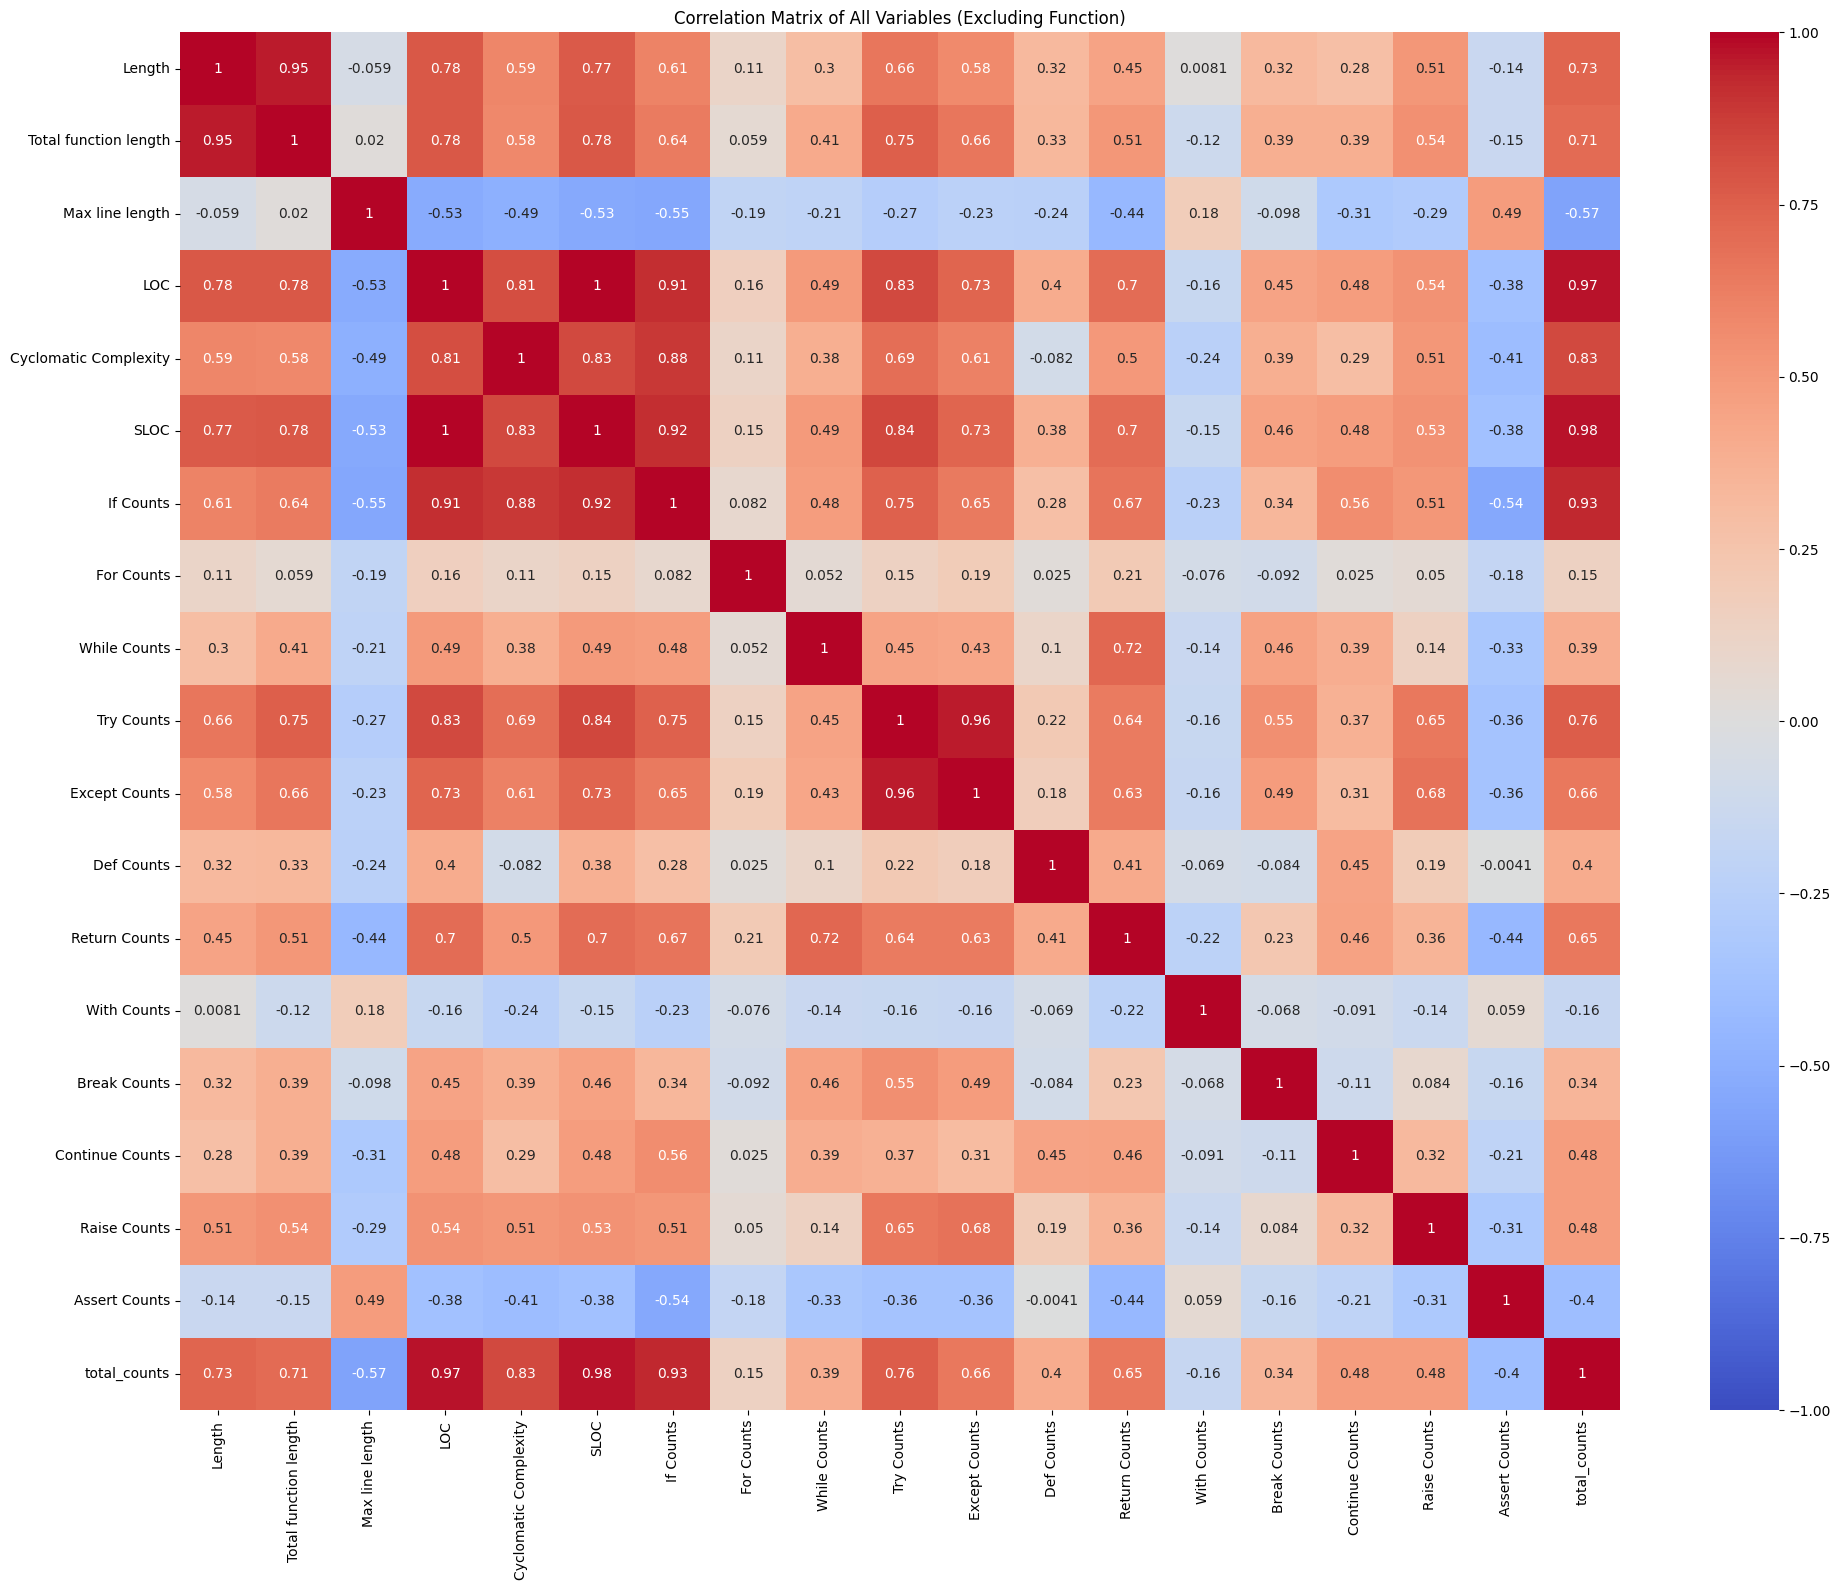

In [13]:
# Calculate the correlation matrix excluding 'Function' column
correlation_matrix = df.drop('Function', axis=1).corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of All Variables (Excluding Function)')
plt.tight_layout()
plt.show()

We can get some common correlation like between try_count and except_count which almost always goes in pair.\
What is interesting is that SLOC is at 77% correlated meaning that the number of calls made in a function are still a big factor of a big token length.

# Conclusion

The length of a function, be it in one line or more, is what makes a function too big for Code T5.